In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv


In [4]:
import string
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.metrics.pairwise import cosine_similarity
train = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv")
test = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv")
print(train.shape, test.shape)
train.head()

(2000, 8) (500, 7)


,id,prompt,A,B,C,D,E,answer
0,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,A
2,3,Determine the correct option: What is the term...,Blueshifting,Redshifting,Reddening,Whitening,Yellowing,C
3,4,Select the most accurate option: What is Marti...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
4,5,Identify the correct statement: What is the co...,"Simultaneity is relative, meaning that two eve...","Simultaneity is relative, meaning that two eve...","Simultaneity is absolute, meaning that two eve...",Simultaneity is a concept that applies only to...,Simultaneity is a concept that applies only to...,A


In [5]:
train.isnull().sum()

id        0
prompt    0
A         0
B         0
C         0
D         0
E         0
answer    0
dtype: int64

Q1 

Counter({'B': 490, 'C': 459, 'A': 369, 'D': 358, 'E': 324})
A → 369
B → 490
C → 459
D → 358
E → 324

most frequent  : ('B', 490)
least frequent : ('E', 324)
sum            : 814


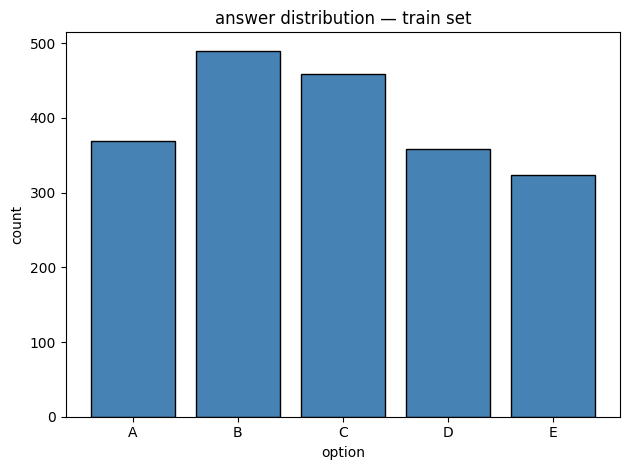

In [6]:
ans_freq = Counter(train["answer"])
print(ans_freq)

for k, v in sorted(ans_freq.items()):
    print(f"{k} → {v}")

most_common  = ans_freq.most_common(1)[0]
least_common = ans_freq.most_common()[-1]

print(f"\nmost frequent  : {most_common}")
print(f"least frequent : {least_common}")
print(f"sum            : {most_common[1] + least_common[1]}")

labels  = sorted(ans_freq.keys())
counts  = [ans_freq[l] for l in labels]

plt.bar(labels, counts, color="steelblue", edgecolor="black")
plt.title("answer distribution — train set")
plt.xlabel("option")
plt.ylabel("count")
plt.tight_layout()
plt.savefig("answer_dist.png", dpi=100)
plt.show()

**Q2**

In [7]:
def clean(text):
    text = text.lower()
    text = text.translate(str.maketrans("", "", string.punctuation))
    return text

train["prompt_clean"] = train["prompt"].apply(clean)

all_words = []
for sent in train["prompt_clean"]:
    all_words.extend(sent.split())

vocab = set(all_words)
print("unique words across all prompts:", len(vocab))

unique words across all prompts: 859


**Q3**

In [8]:
row1 = train[train["id"] == 1].iloc[0]
cleaned_prompt = clean(row1["prompt"])

words_raw      = cleaned_prompt.split()
words_filtered = [w for w in words_raw if w not in ENGLISH_STOP_WORDS]

print("before:", words_raw)
print("after :", words_filtered)
print("count :", len(words_filtered))

before: ['pick', 'the', 'best', 'possible', 'answer', 'what', 'is', 'martin', 'heideggers', 'view', 'on', 'the', 'relationship', 'between', 'time', 'and', 'human', 'existence', 'among', 'the', 'listed', 'options']
after : ['pick', 'best', 'possible', 'answer', 'martin', 'heideggers', 'view', 'relationship', 'time', 'human', 'existence', 'listed', 'options']
count : 13


**Q4**

In [9]:
corpus = []
for _, r in train.iterrows():
    corpus.append(r["prompt"])
    for col in ["A", "B", "C", "D", "E"]:
        corpus.append(r[col])

tfidf = TfidfVectorizer(stop_words="english")
tfidf.fit(corpus)

print("feature columns (vocab size):", len(tfidf.vocabulary_))

feature columns (vocab size): 2762


**Q5**

In [10]:
pv = tfidf.transform([row1["prompt"]])
av = tfidf.transform([row1["A"]])

score = cosine_similarity(pv, av)[0][0]
print("cosine sim (prompt vs A, row 1):", round(score, 4))

cosine sim (prompt vs A, row 1): 0.2328


**Q6**

In [11]:
hits = 0
for _, r in train.iterrows():
    pv = tfidf.transform([r["prompt"]])
    
    sims = {}
    for col in ["A", "B", "C", "D", "E"]:
        ov = tfidf.transform([r[col]])
        sims[col] = cosine_similarity(pv, ov)[0][0]
    
    top_pick = max(sims, key=sims.get)
    if top_pick == r["answer"]:
        hits += 1

print(f"top-1 accuracy: {round(hits / len(train) * 100, 2)}%")
print("(random chance would be 20%, so this is actually worse — makes sense)")

top-1 accuracy: 13.7%
(random chance would be 20%, so this is actually worse — makes sense)


In [18]:
def ap3(actual, predicted):
    score = 0.0
    hits  = 0
    for i, p in enumerate(predicted[:3]):
        if p == actual:
            hits  += 1
            score += hits / (i + 1)
    return score

def map3(actuals, predictions):
    return np.mean([ap3(a, p) for a, p in zip(actuals, predictions)])

**Q7**

In [13]:
print(ap3("C", ["C", "A", "B"]))

1.0


**Q8**

In [14]:
print(ap3("B", ["D", "B", "E"]))

0.5


**Q9**

In [16]:
top3_static = [x[0] for x in ans_freq.most_common(3)]
print("top 3 most frequent:", top3_static)

preds   = [top3_static] * len(train)
actuals = list(train["answer"])

print("majority baseline MAP@3:", round(map3(actuals, preds), 4))


top 3 most frequent: ['B', 'C', 'A']
majority baseline MAP@3: 0.4212


**Q10**

In [17]:
tfidf_preds = []

for _, r in train.iterrows():
    pv = tfidf.transform([r["prompt"]])
    
    sims = {}
    for col in ["A", "B", "C", "D", "E"]:
        ov = tfidf.transform([r[col]])
        sims[col] = cosine_similarity(pv, ov)[0][0]
    
    ranked = sorted(sims, key=sims.get, reverse=True)[:3]
    tfidf_preds.append(ranked)

print("tfidf pipeline MAP@3:", round(map3(actuals, tfidf_preds), 4))

rows = []

for _, r in test.iterrows():
    pv = tfidf.transform([r["prompt"]])
    
    sims = {}
    for col in ["A", "B", "C", "D", "E"]:
        ov = tfidf.transform([r[col]])
        sims[col] = cosine_similarity(pv, ov)[0][0]
    
    top3 = sorted(sims, key=sims.get, reverse=True)[:3]
    rows.append({"id": r["id"], "prediction": " ".join(top3)})

sub = pd.DataFrame(rows)
sub.to_csv("submission.csv", index=False)
print("done")
sub.head()

tfidf pipeline MAP@3: 0.3119
done


,id,prediction
0,1,A B C
1,2,A B C
2,3,A D C
3,4,A E C
4,5,A C E
